# WorkforceIQ — Attrition Risk Model

Scores every currently-active Everline Corp employee for flight risk and writes
the result back into `attrition_risk_scores`, which the Power BI **Watchlist**
page and the hosted web dashboard both read.

**Deliberately lightweight.** This is not an MLOps showcase — it is the step
that turns a retrospective SQL/BI project into an operational one. What it has
to demonstrate is: a clean train/test split, honest handling of a minority
class, a real model comparison, and coefficients someone can actually explain
to an HR business partner.

### Why logistic regression is the primary model

When HR tells a manager that a named person is a flight risk, the very next
question is *"why?"* — and a coefficient answers that in one sentence. A
Random Forest is trained alongside as a check that the linear form is not
leaving accuracy on the table. If the forest wins by a wide margin, the linear
model is wrong. If it does not, interpretability is free.

### Features come from the SQL views, not from pandas

The modelling frame is assembled by querying the **same views the dashboard
reads** (`vw_compensation_percentile`, `vw_employee_latest_review`,
`vw_employee_tenure`). If the definition of "pay percentile within role"
changes, it changes in one place and the model and the report move together.
A model whose feature definitions drift away from the BI layer is how you end
up explaining why two numbers on the same screen disagree.

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent / "generators"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from feature_store import load_features, NUMERIC_FEATURES, CATEGORICAL_FEATURES

plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25})
ACCENT, WARN, INK = "#2563eb", "#dc2626", "#1f2937"

df = load_features()
print(df.shape)
df.head(3)

(1470, 25)


,employee_id,attrition_flag,current_status,tenure_years,tenure_years_log,age,job_level,distance_from_home,monthly_income,income_pct_rank_in_role,...,work_life_balance,performance_rating,overtime,manager_span,department_name,job_role,marital_status,education_level,business_travel,gender
0,1,1,Terminated,6.90,2.066863,41,2,1,5993,0.458,...,1,3,1,24,Sales,Sales Executive,Single,College,Travel_Rarely,Female
1,2,0,Active,10.78,2.466403,49,2,8,5130,0.924,...,3,4,0,20,Engineering,Software Engineer,Married,Below College,Travel_Frequently,Male
2,4,1,Terminated,0.71,0.536493,37,1,2,2090,0.089,...,3,3,1,13,Engineering,QA Engineer,Single,College,Travel_Rarely,Male


## 1. The class imbalance decides which metrics are allowed

Only 16% of employees left. A model that predicts *"nobody ever leaves"* scores
84% accuracy and is completely useless. Accuracy is therefore off the table for
the rest of this notebook; everything is judged on **recall** and **PR-AUC**.

For a retention watchlist that trade-off is the right one on the business side
too: a false positive costs a manager one coffee conversation, a false negative
costs a replacement hire — commonly quoted at 6–9 months of salary.

In [2]:
y = df["attrition_flag"].astype(int)
X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]

print(f"employees      : {len(df):,}")
print(f"leavers        : {y.sum():,}")
print(f"base rate      : {y.mean():.4f}")
print(f"accuracy of a 'nobody leaves' model: {1 - y.mean():.4f}  <- the number to beat is not this one")

employees      : 1,470
leavers        : 237
base rate      : 0.1612
accuracy of a 'nobody leaves' model: 0.8388  <- the number to beat is not this one


## 2. Tenure is sharply non-linear — which shapes the feature set

Attrition collapses over the first three years and then flattens. A raw linear
tenure term cannot represent that curve, so `LN(1 + tenure)` is added in the
feature view. This is also the main reason a tree model is worth comparing
against: a forest finds this shape on its own.

,employees,attrition_rate
tenure_years,,
"(-0.01, 1.0]",45,0.378
"(1.0, 2.0]",171,0.339
"(2.0, 3.0]",127,0.213
"(3.0, 5.0]",240,0.162
"(5.0, 10.0]",523,0.113
"(10.0, 15.0]",206,0.112
"(15.0, 45.0]",158,0.089


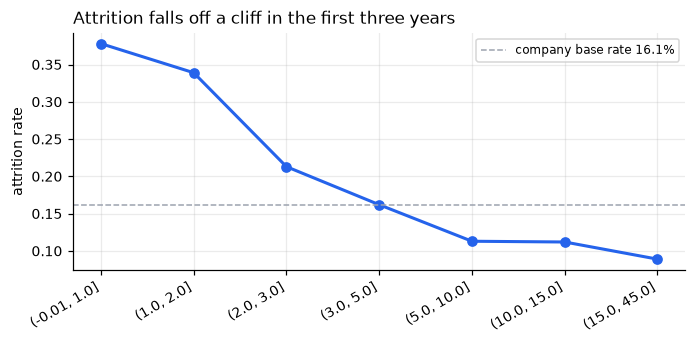

In [3]:
bands = pd.cut(df.tenure_years, [-0.01, 1, 2, 3, 5, 10, 15, 45])
curve = df.groupby(bands, observed=True).agg(
    employees=("attrition_flag", "size"),
    attrition_rate=("attrition_flag", "mean"),
).round(3)
display(curve)

fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.plot(range(len(curve)), curve.attrition_rate, "o-", color=ACCENT, lw=2)
ax.axhline(y.mean(), ls="--", color="#9ca3af", lw=1, label=f"company base rate {y.mean():.1%}")
ax.set_xticks(range(len(curve)), [str(i) for i in curve.index], rotation=30, ha="right")
ax.set_ylabel("attrition rate")
ax.set_title("Attrition falls off a cliff in the first three years", loc="left")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 3. Pipeline and split

Imputation, scaling and one-hot encoding all live **inside** the pipeline so
they are fit on the training fold only. Doing the scaling before the split is
the classic leak — the test set's mean would inform the training transform.

Both models use balanced class weights.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42

def make_preprocessor():
    numeric = Pipeline([("impute", SimpleImputer(strategy="median")),
                        ("scale", StandardScaler())])
    categorical = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                            ("onehot", OneHotEncoder(handle_unknown="ignore",
                                                     drop="first", sparse_output=False))])
    return ColumnTransformer([("num", numeric, NUMERIC_FEATURES),
                              ("cat", categorical, CATEGORICAL_FEATURES)])

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

logreg = Pipeline([("pre", make_preprocessor()),
                   ("clf", LogisticRegression(max_iter=3000, class_weight="balanced",
                                              C=0.5, random_state=RANDOM_STATE))])
forest = Pipeline([("pre", make_preprocessor()),
                   ("clf", RandomForestClassifier(n_estimators=500, min_samples_leaf=3,
                                                  max_features="sqrt",
                                                  class_weight="balanced_subsample",
                                                  n_jobs=-1, random_state=RANDOM_STATE))])

logreg.fit(X_tr, y_tr)
forest.fit(X_tr, y_tr)
print(f"train {len(X_tr):,}   test {len(X_te):,}   test leavers {y_te.sum()}")

train 1,102   test 368   test leavers 59


## 4. Held-out performance

In [5]:
from sklearn.metrics import (average_precision_score, classification_report,
                             confusion_matrix, precision_recall_curve,
                             roc_auc_score, roc_curve)

def report(name, pipe):
    proba = pipe.predict_proba(X_te)[:, 1]
    pred = (proba >= 0.5).astype(int)
    print(f"===== {name} =====")
    print(classification_report(y_te, pred, target_names=["Stayed", "Left"], zero_division=0))
    print(f"ROC-AUC {roc_auc_score(y_te, proba):.4f}   PR-AUC {average_precision_score(y_te, proba):.4f}")
    print("confusion matrix [[tn fp][fn tp]]:")
    print(confusion_matrix(y_te, pred), "\n")
    return proba

lr_proba = report("Logistic Regression", logreg)
rf_proba = report("Random Forest", forest)

===== Logistic Regression =====
              precision    recall  f1-score   support

      Stayed       0.92      0.77      0.84       309
        Left       0.35      0.66      0.46        59

    accuracy                           0.75       368
   macro avg       0.64      0.72      0.65       368
weighted avg       0.83      0.75      0.78       368

ROC-AUC 0.7391   PR-AUC 0.4796
confusion matrix [[tn fp][fn tp]]:
[[238  71]
 [ 20  39]] 

===== Random Forest =====
              precision    recall  f1-score   support

      Stayed       0.87      0.97      0.91       309
        Left       0.57      0.22      0.32        59

    accuracy                           0.85       368
   macro avg       0.72      0.59      0.62       368
weighted avg       0.82      0.85      0.82       368

ROC-AUC 0.7486   PR-AUC 0.4062
confusion matrix [[tn fp][fn tp]]:
[[299  10]
 [ 46  13]] 



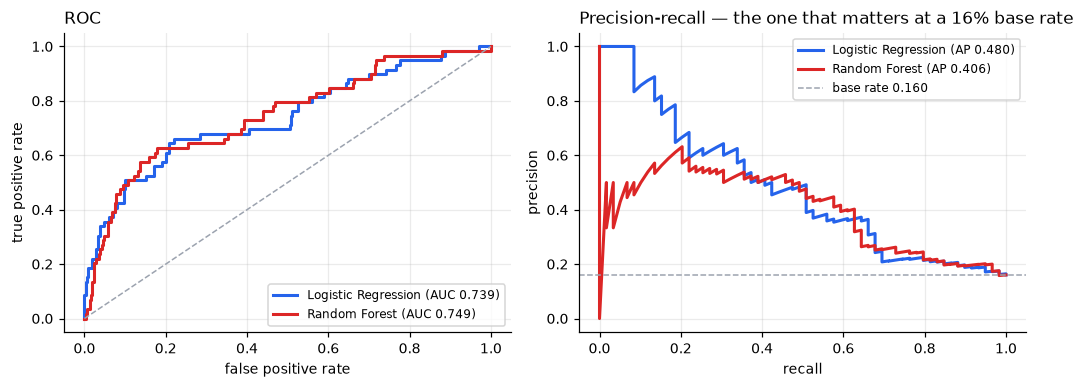

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6))

for nm, proba, col in [("Logistic Regression", lr_proba, ACCENT), ("Random Forest", rf_proba, WARN)]:
    fpr, tpr, _ = roc_curve(y_te, proba)
    axes[0].plot(fpr, tpr, color=col, lw=2, label=f"{nm} (AUC {roc_auc_score(y_te, proba):.3f})")
    pr, rc, _ = precision_recall_curve(y_te, proba)
    axes[1].plot(rc, pr, color=col, lw=2, label=f"{nm} (AP {average_precision_score(y_te, proba):.3f})")

axes[0].plot([0, 1], [0, 1], "--", color="#9ca3af", lw=1)
axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate")
axes[0].set_title("ROC", loc="left"); axes[0].legend(fontsize=8, loc="lower right")

axes[1].axhline(y_te.mean(), ls="--", color="#9ca3af", lw=1, label=f"base rate {y_te.mean():.3f}")
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
axes[1].set_title("Precision-recall — the one that matters at a 16% base rate", loc="left")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. Cross-validated comparison

One split is not enough to choose a model, especially with 59 positive cases in
the test set. Five-fold stratified CV on the full dataset gives a fairer read
and, importantly, a **standard deviation** to judge whether any gap is real.

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}
for name, pipe in [("Logistic Regression", logreg), ("Random Forest", forest)]:
    s = cross_val_score(pipe, X, y, cv=cv, scoring="average_precision")
    cv_results[name] = (s.mean(), s.std())
    print(f"{name:22s} PR-AUC {s.mean():.4f} +/- {s.std():.4f}")

gap = abs(cv_results["Random Forest"][0] - cv_results["Logistic Regression"][0])
pooled_sd = max(cv_results["Random Forest"][1], cv_results["Logistic Regression"][1])
print(f"\ngap {gap:.4f} vs fold-to-fold sd {pooled_sd:.4f} -> "
      f"{'within noise; models are tied' if gap < pooled_sd else 'a real difference'}")

Logistic Regression    PR-AUC 0.5069 +/- 0.0646


Random Forest          PR-AUC 0.5113 +/- 0.0341

gap 0.0043 vs fold-to-fold sd 0.0646 -> within noise; models are tied


**Result: the two models are statistically tied.** The gap between them is well
inside the fold-to-fold standard deviation, so the forest buys no real accuracy.

That settles the choice: **ship the logistic regression.** Interpretability is
free here, and the forest's advantage on the single split was noise. Both are
scored and written to the database anyway so the dashboard can show them side by
side — but the watchlist ranks on the linear model.

## 6. What actually drives attrition

Two complementary readings:

- **Coefficients** — direction and magnitude on standardised features, so they
  are comparable to each other. Exponentiated, they are odds ratios.
- **Permutation importance** — how much PR-AUC is lost when a column is
  shuffled. This is the more trustworthy ranking, because it is measured on
  held-out data and is not fooled by correlated predictors sharing credit.

Note that `tenure_years` and `tenure_years_log` are collinear by construction —
they encode one curved effect between them and should be read as a pair, not as
two independent findings.

In [8]:
pre = logreg.named_steps["pre"]
cat_names = pre.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(CATEGORICAL_FEATURES)
names = NUMERIC_FEATURES + list(cat_names)

coef_df = (pd.DataFrame({"feature": names, "coefficient": logreg.named_steps["clf"].coef_[0]})
           .assign(odds_ratio=lambda d: np.exp(d.coefficient),
                   abs_coef=lambda d: d.coefficient.abs())
           .sort_values("abs_coef", ascending=False)
           .drop(columns="abs_coef")
           .reset_index(drop=True))
display(coef_df.head(15).round(3))

,feature,coefficient,odds_ratio
0,business_travel_Travel_Frequently,1.300,3.671
1,job_role_QA Engineer,0.989,2.688
2,tenure_years_log,-0.970,0.379
3,tenure_years,0.867,2.379
4,job_role_Support Representative,-0.832,0.435
5,marital_status_Single,0.819,2.268
6,overtime,0.779,2.179
7,department_name_Sales,0.770,2.159
8,job_role_Sales Representative,0.646,1.907
9,monthly_income,-0.564,0.569


In [9]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(logreg, X_te, y_te, n_repeats=15,
                              random_state=RANDOM_STATE,
                              scoring="average_precision", n_jobs=-1)
perm_df = (pd.DataFrame({"feature": X_te.columns,
                         "drop_in_pr_auc": perm.importances_mean,
                         "std": perm.importances_std})
           .sort_values("drop_in_pr_auc", ascending=False).reset_index(drop=True))
display(perm_df.head(12).round(4))

,feature,drop_in_pr_auc,std
0,tenure_years_log,0.2199,0.0297
1,overtime,0.1784,0.0411
2,monthly_income,0.1024,0.0233
3,tenure_years,0.0922,0.0449
4,job_role,0.0594,0.0235
5,pct_vs_role_average,0.0438,0.0157
6,department_name,0.0395,0.0243
7,job_satisfaction,0.0359,0.0164
8,environment_satisfaction,0.0330,0.0165
9,age,0.0305,0.0115


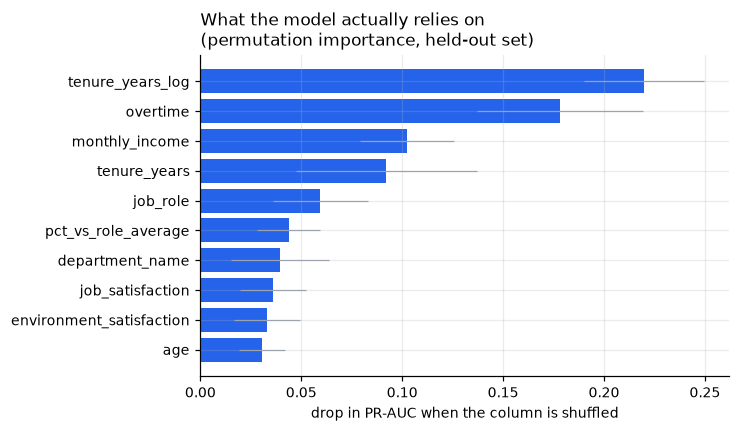

In [10]:
top = perm_df.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(6.8, 4))
ax.barh(top.feature, top.drop_in_pr_auc, xerr=top["std"],
        color=ACCENT, error_kw={"lw": 0.8, "ecolor": "#9ca3af"})
ax.set_xlabel("drop in PR-AUC when the column is shuffled")
ax.set_title("What the model actually relies on\n(permutation importance, held-out set)", loc="left")
plt.tight_layout(); plt.show()

### Reading the drivers

The ranking is consistent with the SQL findings, which is the reassuring part —
two independent methods on the same data agreeing:

1. **Tenure** (log + linear together) — the largest single effect, matching the
   36.4% → 10.4% cohort gradient in `vw_tenure_cohort_attrition`.
2. **Overtime** — the strongest *actionable* driver, and the one the business can
   change tomorrow. Matches the 2.27× lift in `vw_overtime_satisfaction_attrition`.
3. **Compensation** — both absolute income and position within role
   (`pct_vs_role_average`), echoing the bottom-quartile effect in
   `vw_compensation_percentile`.
4. **Satisfaction and environment scores** — real, but smaller than the intuition
   suggests once the others are accounted for.

`business_travel_Travel_Frequently` carries the single largest coefficient
(odds ratio ≈ 3.7). It is a strong flag but sits on a smaller slice of the
population, which is why it ranks lower on permutation importance than on
coefficient magnitude — a good illustration of why both views are shown.

## 7. Scoring the active population

Two decisions here that are easy to get wrong:

**Refit on everything before scoring.** The metrics above come from the held-out
split — that is what they are for. But the model that goes into production
should see every labelled example available.

**Tier by quantile, not by a 0.5 probability cutoff.** Under balanced class
weights a 0.5 threshold flags several hundred people, which no HR team can
action. The top decile is a list a business partner can actually work through
in a month. This is a capacity decision, not a statistical one, and it belongs
in the open.

In [11]:
HIGH_Q, MED_Q = 0.90, 0.70
SCORED_DATE = pd.Timestamp("2025-12-31").date()

logreg.fit(X, y)
forest.fit(X, y)

active = df[df.current_status == "Active"].copy()
X_active = active[NUMERIC_FEATURES + CATEGORICAL_FEATURES]

frames = []
for model_name, pipe in [("logistic_regression", logreg), ("random_forest", forest)]:
    s = pipe.predict_proba(X_active)[:, 1]
    hi, med = np.quantile(s, HIGH_Q), np.quantile(s, MED_Q)
    tier = np.where(s >= hi, "High", np.where(s >= med, "Medium", "Low"))
    frames.append(pd.DataFrame({"employee_id": active.employee_id.values,
                                "scored_date": SCORED_DATE,
                                "risk_score": np.round(s, 5),
                                "risk_tier": tier,
                                "model_name": model_name}))
    print(f"{model_name:22s} High>={hi:.3f}  Medium>={med:.3f}  "
          f"High n={(tier=='High').sum()}  Medium n={(tier=='Medium').sum()}")

scored = pd.concat(frames, ignore_index=True)
out = Path.cwd().parent / "data" / "processed" / "attrition_risk_scores.csv"
scored.to_csv(out, index=False)
print(f"\nwrote {len(scored):,} rows -> {out.name}")

logistic_regression    High>=0.677  Medium>=0.448  High n=124  Medium n=246
random_forest          High>=0.290  Medium>=0.175  High n=124  Medium n=246

wrote 2,466 rows -> attrition_risk_scores.csv


### The watchlist as HR would see it

A score on its own gets ignored. The flags are what make it a conversation.

In [12]:
watch = (active.merge(scored[scored.model_name == "logistic_regression"], on="employee_id")
         .sort_values("risk_score", ascending=False))
watch["flags"] = (
    np.where(watch.overtime == 1, "overtime ", "")
    + np.where(watch.job_satisfaction <= 2, "low-satisfaction ", "")
    + np.where(watch.work_life_balance <= 2, "poor-WLB ", "")
    + np.where(watch.income_pct_rank_in_role <= 0.25, "bottom-pay-quartile ", "")
    + np.where(watch.tenure_years <= 3, "early-tenure ", "")
)
display(watch.head(12)[["employee_id", "department_name", "job_role", "risk_score",
                        "risk_tier", "tenure_years", "flags"]].round(3))

print(watch.groupby("department_name").risk_tier.value_counts().unstack(fill_value=0)
      [["High", "Medium", "Low"]])

,employee_id,department_name,job_role,risk_score,risk_tier,tenure_years,flags
1199,2021,Sales,Sales Representative,0.964,High,2.82,overtime low-satisfaction early-tenure
1156,1961,Sales,Sales Representative,0.940,High,1.52,low-satisfaction poor-WLB early-tenure
934,1594,Engineering,QA Engineer,0.922,High,3.91,overtime low-satisfaction
622,1036,Sales,Sales Executive,0.913,High,1.10,overtime early-tenure
294,467,Sales,Sales Representative,0.903,High,0.18,early-tenure
928,1586,Engineering,QA Engineer,0.899,High,10.87,overtime low-satisfaction
824,1402,Engineering,Software Engineer,0.893,High,20.72,overtime poor-WLB
485,803,Operations,Operations Director,0.890,High,15.93,overtime low-satisfaction
754,1269,Engineering,Software Engineer,0.884,High,1.80,overtime early-tenure
50,81,Sales,Sales Executive,0.882,High,21.62,low-satisfaction poor-WLB


risk_tier         High  Medium  Low
department_name                    
Customer Support     5      11  106
Engineering         56     110  354
Finance              1       9   87
HR                   7      12   21
Operations           5      17  113
Sales               50      87  182


## 8. Sanity check — the model vs a rule a human would write

Before trusting a model, it is worth asking whether it is doing anything a
weighted checklist could not. The DAX measure `Flight Risk Score (Rule-Based)`
in the Power BI report implements exactly this heuristic, so the report can put
the two side by side.

correlation heuristic vs model : 0.465
top-decile overlap             : 47.6%


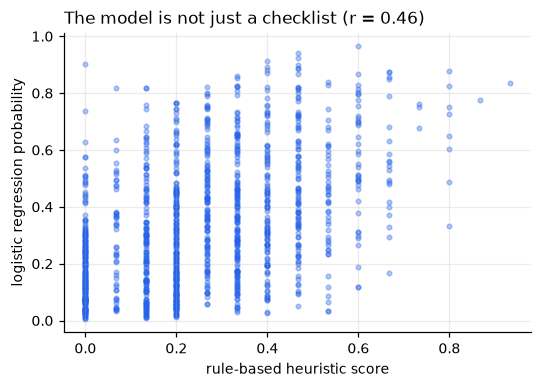

In [13]:
a = active
heuristic = (2.0 * (a.overtime == 1)
             + 1.5 * (a.job_satisfaction <= 2)
             + 1.0 * (a.work_life_balance <= 2)
             + 1.5 * (a.income_pct_rank_in_role <= 0.25)
             + 1.0 * ((a.tenure_years >= 1) & (a.tenure_years <= 3))
             + 0.5 * (a.distance_from_home >= 20)) / 7.5

lr = scored[scored.model_name == "logistic_regression"].set_index("employee_id")
model_score = lr.loc[a.employee_id, "risk_score"].astype(float).values
r = np.corrcoef(heuristic.fillna(0).values, model_score)[0, 1]

top_h = set(a.employee_id[heuristic >= heuristic.quantile(0.90)])
top_m = set(lr[lr.risk_tier == "High"].index)
overlap = len(top_h & top_m) / len(top_m)

print(f"correlation heuristic vs model : {r:.3f}")
print(f"top-decile overlap             : {overlap:.1%}")

fig, ax = plt.subplots(figsize=(5, 3.6))
ax.scatter(heuristic, model_score, s=9, alpha=0.35, color=ACCENT)
ax.set_xlabel("rule-based heuristic score"); ax.set_ylabel("logistic regression probability")
ax.set_title(f"The model is not just a checklist (r = {r:.2f})", loc="left")
plt.tight_layout(); plt.show()

**They agree less than half the time.** Correlation is moderate and the two
approaches pick overlapping-but-different top deciles.

That gap is the model earning its place. The heuristic weights every overtime
employee identically; the model knows that overtime on a 2-year Sales
Representative in the bottom pay quartile is a very different proposition from
overtime on a 12-year Finance Manager. Shipping both — and showing them next to
each other in the report — means the model can be challenged rather than
trusted blindly.

## 9. Limitations, stated rather than buried

- **Point-in-time features.** `tenure_years` is measured at termination for
  leavers and at the snapshot date for active employees, because that is how the
  source encodes `YearsAtCompany`. An earlier version of the data generator made
  this worse by jittering hire dates for active employees only, which put every
  leaver on an exact integer tenure and produced an implausible 71% attrition
  rate in the under-1-year band — a class-dependent artefact the model happily
  exploited. It is fixed, but the episode is the point: **in production this
  needs a real feature store snapshotting every employee at a fixed lookback
  date.**
- **Sample size.** 237 positive cases. Wide confidence intervals on everything;
  the fold-to-fold PR-AUC standard deviation of ~0.06 is the honest measure of
  how much precision to claim.
- **No causal claim.** These are associations. "Overtime predicts leaving" is not
  "cutting overtime will stop people leaving" — though finding 5 makes it the
  best-supported lever available.
- **Drift.** `attrition_risk_scores` keeps every scoring run precisely so that
  drift is observable. Nothing currently monitors it. See the production section
  of the README.